
# Part 1: Data Audit, EDA & Business Understanding



## Setup & Imports

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

## 1. Load datasets



In [3]:
customers = pd.read_csv("data\customers.csv")
orders = pd.read_csv("data\orders.csv")
tickets = pd.read_csv("data\support_tickets.csv")
web = pd.read_csv("data\web_events_snapshot.csv")
churn = pd.read_csv("data\churn_labels.csv")
intervention = pd.read_csv("data\intervention_history.csv")

In [4]:
#Shape Summary
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Tickets:", tickets.shape)
print("Web Events:", web.shape)
print("Churn:", churn.shape)
print("Intervention", intervention.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Tickets: (1921, 8)
Web Events: (2400, 10)
Churn: (2400, 4)
Intervention (2400, 5)


## 2. Dataset Inspection

In [5]:
print(customers.info())
print('\n')
print(customers.head())

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB
None


  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram   
1   CUST00002  2025-06-01    Tier 2     25-34         Marketplace   
2   CUST00003  2025-03-08    Tier 1     25-34          Influencer   
3   CUST00004  2025-04-15    Tier 3     25-34       Goog

In [6]:
print(orders.info())
print('\n')
print(orders.head())

<class 'pandas.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  str    
 1   customer_id    10009 non-null  str    
 2   order_date     10009 non-null  str    
 3   category       10009 non-null  str    
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 782.1 KB
None


    order_id customer_id  order_date   category  quantity  gross_amount  \
0  ORD000001   CUST00001  2024-08-06  Skin Care         1        540.70   
1  ORD000002   CUST00001  2024-10-23  Hair Care         2        467.96   
2  ORD000006   CUST00001  2025-01-18     Makeup         1        581.81   
3  ORD0

In [7]:
print(tickets.info())
print('\n')
print(tickets.head())

<class 'pandas.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   str    
 1   customer_id       1921 non-null   str    
 2   ticket_date       1921 non-null   str    
 3   issue_type        1921 non-null   str    
 4   support_channel   1921 non-null   str    
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), str(5)
memory usage: 120.2 KB
None


   ticket_id customer_id ticket_date     issue_type support_channel  \
0  TKT000001   CUST00001  2024-10-28   damaged_item            chat   
1  TKT000002   CUST00001  2025-02-03  payment_issue            chat   
2  TKT000003   CUST00002  2025-08-30  late_delivery            chat   
3  TKT000004   CUST00005  2025-05-02  late_delivery            call   
4  TKT000005 

In [8]:
print(web.info())
print('\n')
print(web.head())

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   snapshot_date        2400 non-null   str  
 2   sessions_30d         2400 non-null   int64
 3   product_views_30d    2400 non-null   int64
 4   cart_adds_30d        2400 non-null   int64
 5   wishlist_adds_30d    2400 non-null   int64
 6   abandoned_carts_30d  2400 non-null   int64
 7   email_opens_30d      2400 non-null   int64
 8   campaign_clicks_30d  2400 non-null   int64
 9   last_visit_days_ago  2400 non-null   int64
dtypes: int64(8), str(2)
memory usage: 187.6 KB
None


  customer_id snapshot_date  sessions_30d  product_views_30d  cart_adds_30d  \
0   CUST00001    2025-09-30             1                  4              0   
1   CUST00002    2025-09-30             8                 31              4   
2   CUST00003    2025-09-30         

In [9]:
print(churn.info())
print('\n')
print(churn.head())

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     2400 non-null   str  
 1   snapshot_date   2400 non-null   str  
 2   churn_next_60d  2400 non-null   int64
 3   split           2400 non-null   str  
dtypes: int64(1), str(3)
memory usage: 75.1 KB
None


  customer_id snapshot_date  churn_next_60d  split
0   CUST00001    2025-09-30               1  train
1   CUST00002    2025-09-30               0  train
2   CUST00003    2025-09-30               1  train
3   CUST00004    2025-09-30               1  train
4   CUST00005    2025-09-30               0  train


In [10]:
print(intervention.info())
print('\n')
print(intervention.head())

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   customer_id             2400 non-null   str  
 1   snapshot_date           2400 non-null   str  
 2   last_campaign_received  2400 non-null   str  
 3   last_campaign_cost      2400 non-null   int64
 4   manual_priority_bucket  2400 non-null   str  
dtypes: int64(1), str(4)
memory usage: 93.9 KB
None


  customer_id snapshot_date last_campaign_received  last_campaign_cost  \
0   CUST00001    2025-09-30          welcome_offer                  25   
1   CUST00002    2025-09-30          free_shipping                  12   
2   CUST00003    2025-09-30                   none                  18   
3   CUST00004    2025-09-30          free_shipping                  40   
4   CUST00005    2025-09-30          welcome_offer                  18   

  manual_priority_bucket  
0                   hi

In [11]:
#converting date to pd.to_datetime

SNAPSHOT_DATE = pd.Timestamp('2025-09-30')
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
tickets['ticket_date'] = pd.to_datetime(tickets['ticket_date'])
web['snapshot_date'] = pd.to_datetime(web['snapshot_date'])
churn['snapshot_date'] = pd.to_datetime(churn['snapshot_date'])
intervention['snapshot_date'] = pd.to_datetime(intervention['snapshot_date'])

## 3. Data Quality Audit

### 3.1 Missing Values

In [12]:
def missing_report(name, df):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    report = report[report['missing_count'] > 0]
    print(f'\n=== {name.capitalize()} Missing Values ===')
    if report.empty:
        print('  No missing values.')
    else:
        print(report)

for name, df in [('customers', customers), ('orders', orders), ('tickets', tickets),
                 ('web_events', web), ('churn_labels', churn), ('intervention', intervention)]:
    missing_report(name, df)


=== Customers Missing Values ===
              missing_count  missing_pct
loyalty_tier           1386        57.75
skin_type               401        16.71

=== Orders Missing Values ===
        missing_count  missing_pct
rating             80          0.8

=== Tickets Missing Values ===
  No missing values.

=== Web_events Missing Values ===
  No missing values.

=== Churn_labels Missing Values ===
  No missing values.

=== Intervention Missing Values ===
  No missing values.


### 3.2 Duplicate Records

In [13]:
dup_orders = orders[orders['order_id'].str.endswith('_DUP')]
print(f'Duplicate Orders: {len(dup_orders)}\n')
print(dup_orders[['order_id','customer_id','order_date','gross_amount']].head())

full_dups = orders.duplicated().sum()
print(f'\nFully duplicate rows in orders: {full_dups}')

dup_customer = customers.duplicated(subset='customer_id').sum()
print(f'Duplicate customer_ids in customers.csv: {dup_customer}')

Duplicate Orders: 12

           order_id customer_id order_date  gross_amount
601   ORD008249_DUP   CUST00153 2025-11-04        321.31
2621  ORD002124_DUP   CUST00628 2025-03-18        410.04
3534  ORD002862_DUP   CUST00837 2025-07-12        952.02
3602  ORD002916_DUP   CUST00848 2025-09-26        547.18
3675  ORD002970_DUP   CUST00869 2024-12-22        818.64

Fully duplicate rows in orders: 0
Duplicate customer_ids in customers.csv: 0


### 3.3 Post-Snapshot Orders (Leakage Check)

In [14]:
post_snap = orders[orders['order_date'] > SNAPSHOT_DATE]
pre_snap  = orders[orders['order_date'] <= SNAPSHOT_DATE]

print(f'Total orders: {len(orders)}')
print(f'Pre-snapshot orders: {len(pre_snap)}')
print(f'Post-snapshot orders: {len(post_snap)}')
print(f'\nPost-snapshot date range: {post_snap["order_date"].min().date()} to {post_snap["order_date"].max().date()}')

Total orders: 10009
Pre-snapshot orders: 8137
Post-snapshot orders: 1872

Post-snapshot date range: 2025-10-01 to 2025-11-29


### 3.4 Outlier Detection

In [15]:
orders_clean = pre_snap[~pre_snap['order_id'].str.endswith('_DUP')].copy()

q99 = orders_clean['gross_amount'].quantile(0.99)
outliers = orders_clean[orders_clean['gross_amount'] > q99]
print(f'99th percentile gross_amount: ₹{q99:.2f}')
print(f'Total Outlier orders: {len(outliers)}\n')
print(outliers[['order_id','customer_id','gross_amount','category']].head(10))

99th percentile gross_amount: ₹2343.24
Total Outlier orders: 82

      order_id customer_id  gross_amount   category
73   ORD000055   CUST00020       2710.51  Skin Care
248  ORD000188   CUST00066       2447.60     Makeup
341  ORD000274   CUST00091       2402.71  Skin Care
560  ORD000454   CUST00146       2447.42  Fragrance
616  ORD000493   CUST00156       2467.83  Skin Care
626  ORD000500   CUST00159       3376.32  Fragrance
629  ORD000505   CUST00161       2752.85     Makeup
799  ORD000628   CUST00197       2480.71  Fragrance
822  ORD000654   CUST00200       2347.96  Skin Care
874  ORD000701   CUST00211      22719.45  Fragrance


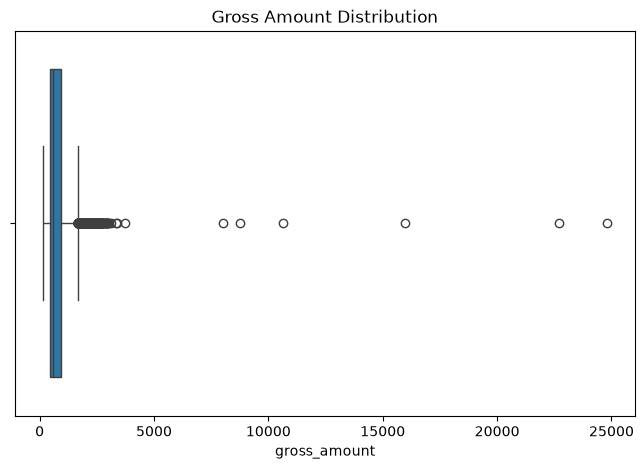

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=orders_clean["gross_amount"]
)

plt.title("Gross Amount Distribution")
plt.show()

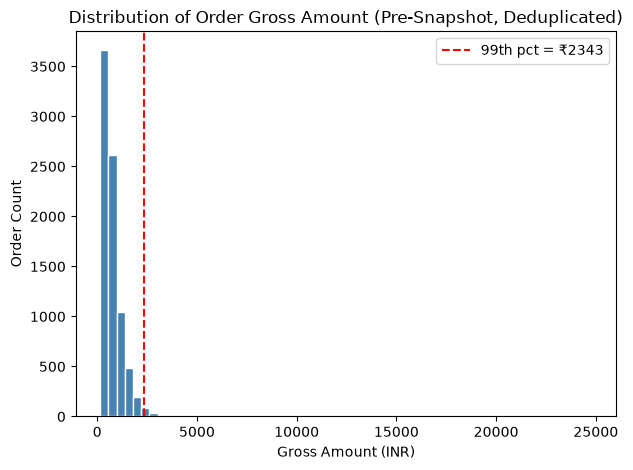

In [17]:
fig, ax = plt.subplots()
ax.hist(orders_clean['gross_amount'], bins=60, color='steelblue', edgecolor='white')
ax.axvline(q99, color='red', linestyle='--', label=f'99th pct = ₹{q99:.0f}')
ax.set_xlabel('Gross Amount (INR)')
ax.set_ylabel('Order Count')
ax.set_title('Distribution of Order Gross Amount (Pre-Snapshot, Deduplicated)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/chart1_gross_amount_distribution.png', dpi=120)
plt.show()

### 3.5 Date Consistency

In [18]:
# Customers who signed up after snapshot
late_signup = customers[customers['signup_date'] > SNAPSHOT_DATE]
print(f'Customers with signup_date after snapshot: {len(late_signup)}')

# Tickets after snapshot 
late_tickets = tickets[tickets['ticket_date'] > SNAPSHOT_DATE]
print(f'Tickets after snapshot date: {len(late_tickets)}')

# Signup after first order 
first_order = orders_clean.groupby('customer_id')['order_date'].min().reset_index()
first_order.columns = ['customer_id', 'first_order_date']
merged_dates = customers.merge(first_order, on='customer_id', how='left')
bad_dates = merged_dates[merged_dates['first_order_date'] < merged_dates['signup_date']]
print(f'Orders placed before signup_date: {len(bad_dates)}')

Customers with signup_date after snapshot: 0
Tickets after snapshot date: 0
Orders placed before signup_date: 0


## 4. Mater Dataset(Joined Table)

In [19]:
print(f'Clean pre-snapshot orders: {len(orders_clean)}')

# Aggregate order features per customer
order_agg = orders_clean.groupby('customer_id').agg(
    total_orders    = ('order_id', 'count'),
    total_spend     = ('gross_amount', 'sum'),
    avg_order_value = ('gross_amount', 'mean'),
    return_rate     = ('returned', 'mean'),
    avg_discount    = ('discount_pct', 'mean'),
    avg_rating      = ('rating', 'mean'),
    last_order_date = ('order_date', 'max'),
    unique_categories = ('category', 'nunique')
).reset_index()
order_agg['recency_days'] = (SNAPSHOT_DATE - order_agg['last_order_date']).dt.days

# Aggregate ticket features per customer
ticket_agg = tickets.groupby('customer_id').agg(
    ticket_count      = ('ticket_id', 'count'),
    avg_sentiment     = ('sentiment_score', 'mean'),
    reopen_rate       = ('reopened', 'mean'),
    avg_resolution_h  = ('resolution_hours', 'mean')
).reset_index()

# join
master_df = customers.copy()
master_df = master_df.merge(churn[['customer_id','churn_next_60d','split']], on='customer_id', how='left')
master_df = master_df.merge(order_agg, on='customer_id', how='left')
master_df = master_df.merge(ticket_agg, on='customer_id', how='left')
master_df = master_df.merge(web.drop(columns='snapshot_date'), on='customer_id', how='left')
master_df = master_df.merge(intervention.drop(columns='snapshot_date'), on='customer_id', how='left')

# Filling ticket count 0 for customers with no tickets
master_df['ticket_count'] = master_df['ticket_count'].fillna(0)

print(f'Master dataset shape: {master_df.shape}\n')
master_df.head(3)

Clean pre-snapshot orders: 8128
Master dataset shape: (2400, 35)



,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,churn_next_60d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,1,...,4,0,0,0,2,0,20,welcome_offer,25,high
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,0,...,31,4,2,3,0,0,0,free_shipping,12,medium
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,1,...,3,0,0,0,0,0,26,none,18,high


## 5. Exploratory Data Analysis

### 5.1 Churn Rate

Churn distribution:
churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


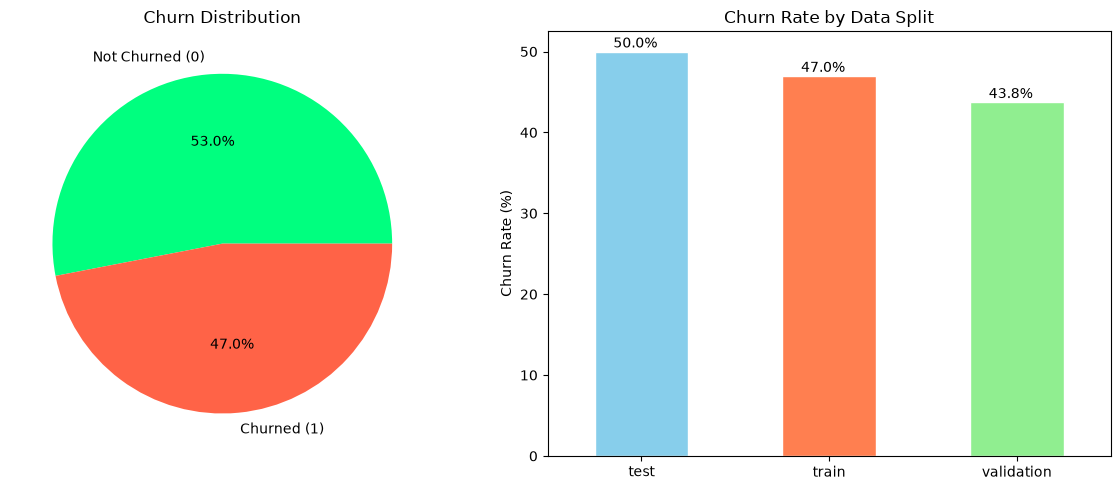

In [20]:
churn_rate = master_df['churn_next_60d'].value_counts(normalize=True) * 100
print('Churn distribution:')
print(churn_rate)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(churn_rate.values, labels=['Not Churned (0)', 'Churned (1)'],
            autopct='%1.1f%%', colors=['springgreen','tomato'])
axes[0].set_title('Churn Distribution')

# churn rate by data split
split_churn = master_df.groupby('split')['churn_next_60d'].mean() * 100
split_churn.plot(kind='bar', ax=axes[1], color=['skyblue','coral','lightgreen'], edgecolor='white')
axes[1].set_title('Churn Rate by Data Split')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.1, p.get_height()+0.5))

plt.tight_layout()
plt.savefig('charts/chart2_churn_distribution.png', dpi=120)
plt.show()

### 5.2 Churn by Acquisition Channel & City Tier

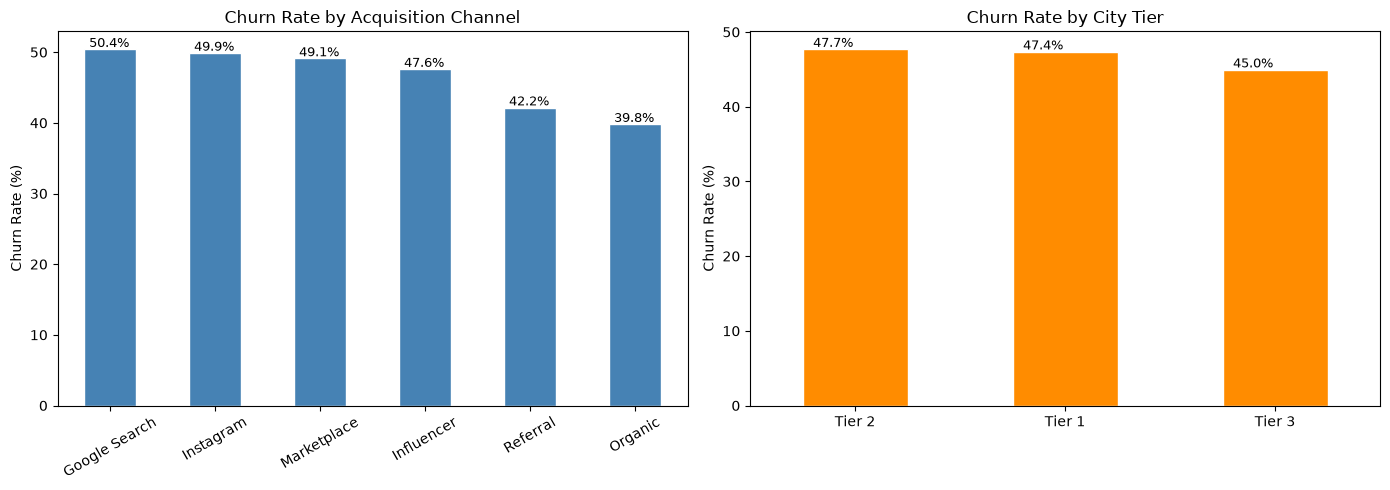

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acquisition channel
ch_churn = master_df.groupby('acquisition_channel')['churn_next_60d'].mean().sort_values(ascending=False) * 100
ch_churn.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Churn Rate by Acquisition Channel')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.05, p.get_height()+0.3), fontsize=9)

# City tier
tier_churn = master_df.groupby('city_tier')['churn_next_60d'].mean().sort_values(ascending=False) * 100
tier_churn.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Churn Rate by City Tier')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.05, p.get_height()+0.3), fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart3_churn_by_channel_tier.png', dpi=120)
plt.show()

### 5.3 Recency vs Churn

Mean recency days by churn label:
churn_next_60d
0     45.074627
1    135.157054
Name: recency_days, dtype: float64


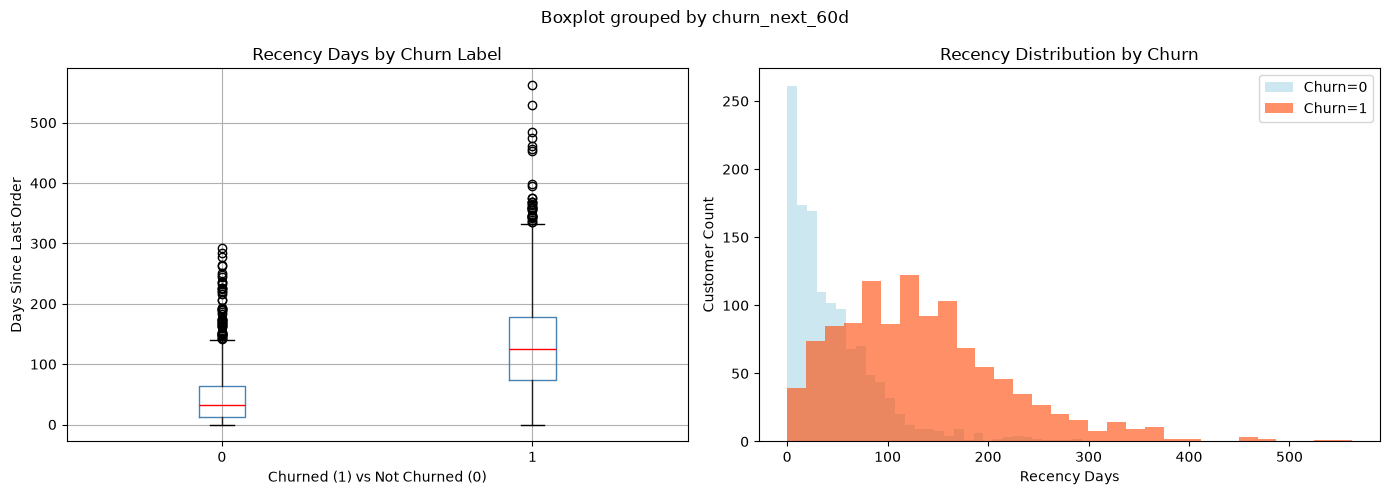

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
master_df.boxplot(column='recency_days', by='churn_next_60d', ax=axes[0],
               boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[0].set_title('Recency Days by Churn Label')
axes[0].set_xlabel('Churned (1) vs Not Churned (0)')
axes[0].set_ylabel('Days Since Last Order')
plt.sca(axes[0])
plt.title('Recency Days by Churn Label')

# Histogram
for label, color in [(0, 'lightblue'), (1, 'orangered')]:
    subset = master_df[master_df['churn_next_60d'] == label]['recency_days'].dropna()
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}')
axes[1].set_title('Recency Distribution by Churn')
axes[1].set_xlabel('Recency Days')
axes[1].set_ylabel('Customer Count')
axes[1].legend()


rec_means = master_df.groupby('churn_next_60d')['recency_days'].mean()
print('Mean recency days by churn label:')
print(rec_means)

plt.tight_layout()
plt.savefig('charts/chart4_recency_vs_churn.png', dpi=120)
plt.show()

### 5.4 Churn bySupport Tickets & Sentiment 

  ticket_bucket      mean  count  churn_rate_pct
0     0 tickets  0.471813   1153       47.181266
1      1 ticket  0.503201    781       50.320102
2     2 tickets  0.436306    314       43.630573
3    3+ tickets  0.348684    152       34.868421


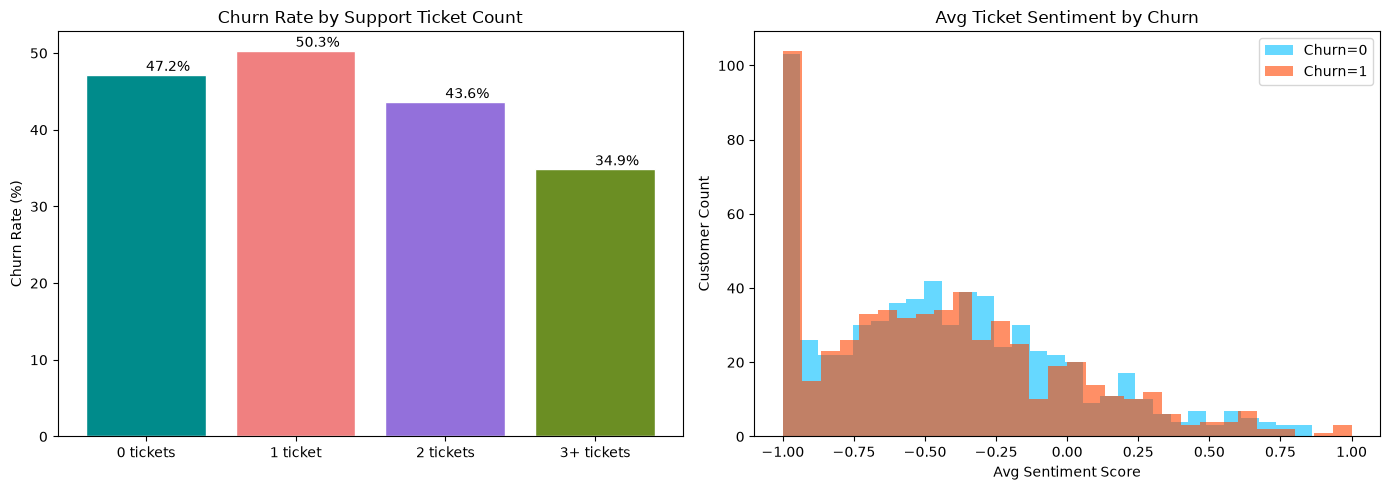

In [23]:
# Bucket ticket counts
master_df['ticket_bucket'] = pd.cut(master_df['ticket_count'], bins=[-1,0,1,2,100],
                                  labels=['0 tickets','1 ticket','2 tickets','3+ tickets'])

ticket_churn = master_df.groupby('ticket_bucket')['churn_next_60d'].agg(['mean','count']).reset_index()
ticket_churn['churn_rate_pct'] = ticket_churn['mean'] * 100
print(ticket_churn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ticket_churn['ticket_bucket'].astype(str), ticket_churn['churn_rate_pct'],
            color=['darkcyan', 'lightcoral', 'mediumpurple', 'olivedrab'], edgecolor='white')
axes[0].set_title('Churn Rate by Support Ticket Count')
axes[0].set_ylabel('Churn Rate (%)')
for i, row in ticket_churn.iterrows():
    axes[0].annotate(f'{row["churn_rate_pct"]:.1f}%', (i, row['churn_rate_pct']+0.5))

# Sentiment vs churn
for label, color in [(0,'deepskyblue'),(1,'orangered')]:
    subset = master_df[master_df['churn_next_60d']==label]['avg_sentiment'].dropna()
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}')
axes[1].set_title('Avg Ticket Sentiment by Churn')
axes[1].set_xlabel('Avg Sentiment Score')
axes[1].set_ylabel('Customer Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/chart5_tickets_vs_churn.png', dpi=120)
plt.show()

### 5.5 Web Activity vs Churn 

Mean web activity by churn label:
                sessions_30d  product_views_30d  cart_adds_30d  \
churn_next_60d                                                   
0                       6.73              28.38           1.95   
1                       4.02              16.97           1.13   

                last_visit_days_ago  
churn_next_60d                       
0                              9.77  
1                             26.55  


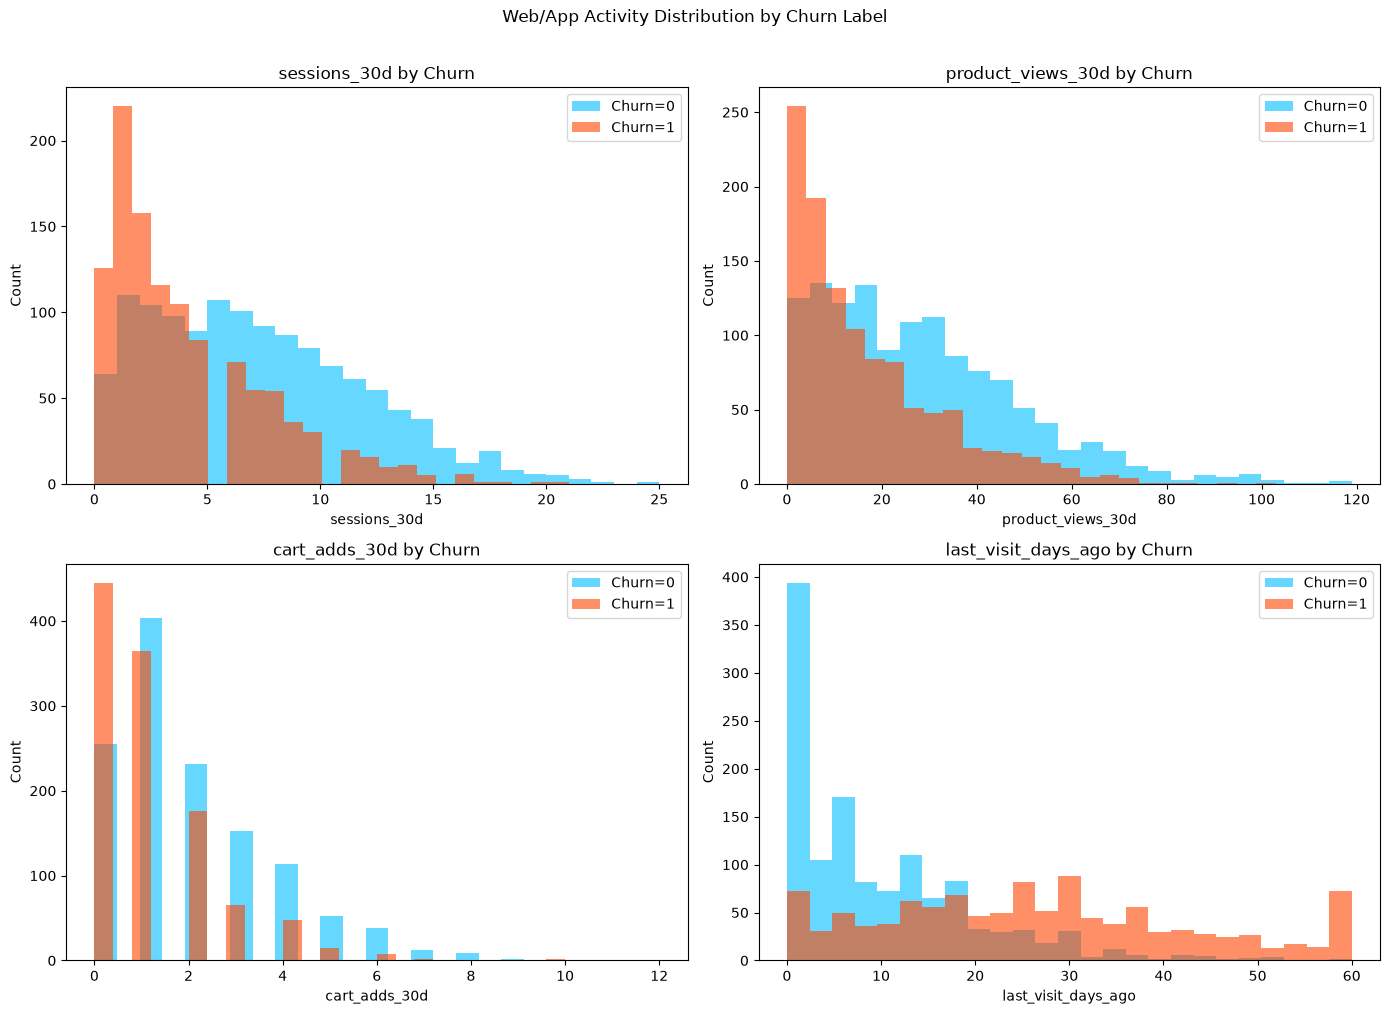

In [24]:
web_cols = ['sessions_30d','product_views_30d','cart_adds_30d','last_visit_days_ago']

web_means = master_df.groupby('churn_next_60d')[web_cols].mean()
print('Mean web activity by churn label:')
print(web_means.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['deepskyblue','orangered']
for idx, col in enumerate(web_cols):
    for label, color in [(0,colors[0]),(1,colors[1])]:
        subset = master_df[master_df['churn_next_60d']==label][col].dropna()
        axes[idx].hist(subset, bins=25, alpha=0.6, color=color, label=f'Churn={label}')
    axes[idx].set_title(f'{col} by Churn')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

plt.suptitle('Web/App Activity Distribution by Churn Label', y=1.01)
plt.tight_layout()
plt.savefig('charts/chart6_web_activity_vs_churn.png', dpi=120)
plt.show()

### 5.6 Loyalty Tier & Return Rate vs Churn

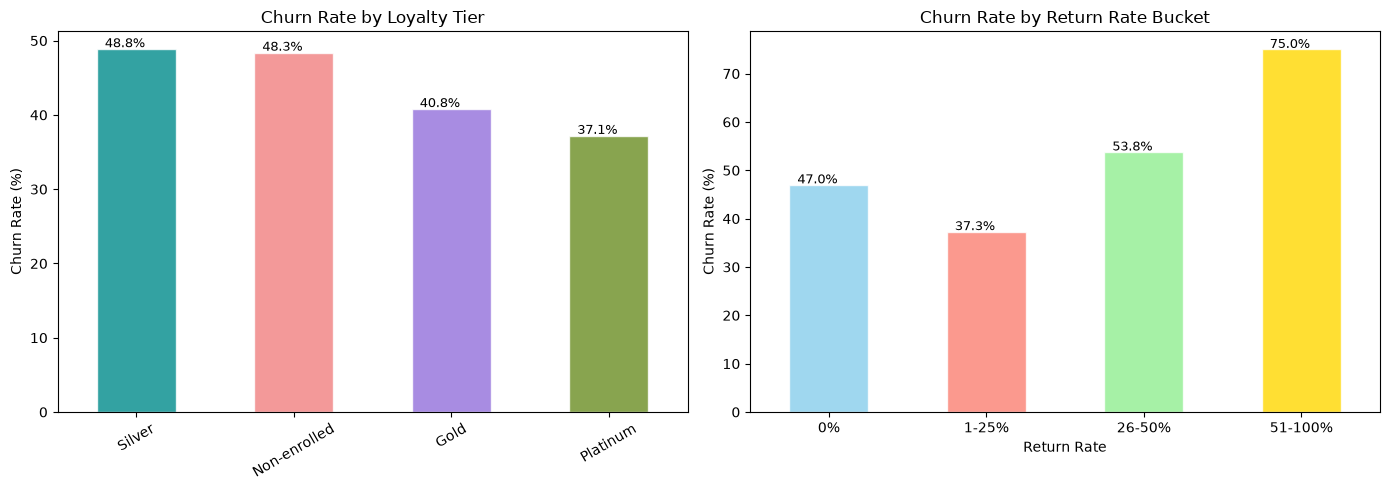

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loyalty tier (including Non-enrolled)
master_df['loyalty_tier_filled'] = master_df['loyalty_tier'].fillna('Non-enrolled')
loy_churn = master_df.groupby('loyalty_tier_filled')['churn_next_60d'].mean().sort_values(ascending=False) * 100
loy_churn.plot(kind='bar', ax=axes[0], color=['darkcyan', 'lightcoral', 'mediumpurple', 'olivedrab'], edgecolor='white', alpha=0.8)
axes[0].set_title('Churn Rate by Loyalty Tier')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.05, p.get_height()+0.3), fontsize=9)

# Return rate vs churn
master_df['return_bucket'] = pd.cut(master_df['return_rate'], bins=[-0.01,0,0.25,0.5,1.01],
                                  labels=['0%','1-25%','26-50%','51-100%'])
ret_churn = master_df.groupby('return_bucket')['churn_next_60d'].mean() * 100
ret_churn.plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon', 'lightgreen', 'gold'], edgecolor='white', alpha=0.8)
axes[1].set_title('Churn Rate by Return Rate Bucket')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Return Rate')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.05, p.get_height()+0.3), fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart7_loyalty_return_churn.png', dpi=120)
plt.show()

### 5.7 Intervention History vs Churn (Chart 8)

  last_campaign_received      mean  count  churn_rate_pct
2             new_launch  0.510040    498       51.004016
0        bundle_discount  0.469345    473       46.934461
1          free_shipping  0.462687    469       46.268657
4          welcome_offer  0.452539    453       45.253863
3                   none  0.451677    507       45.167653


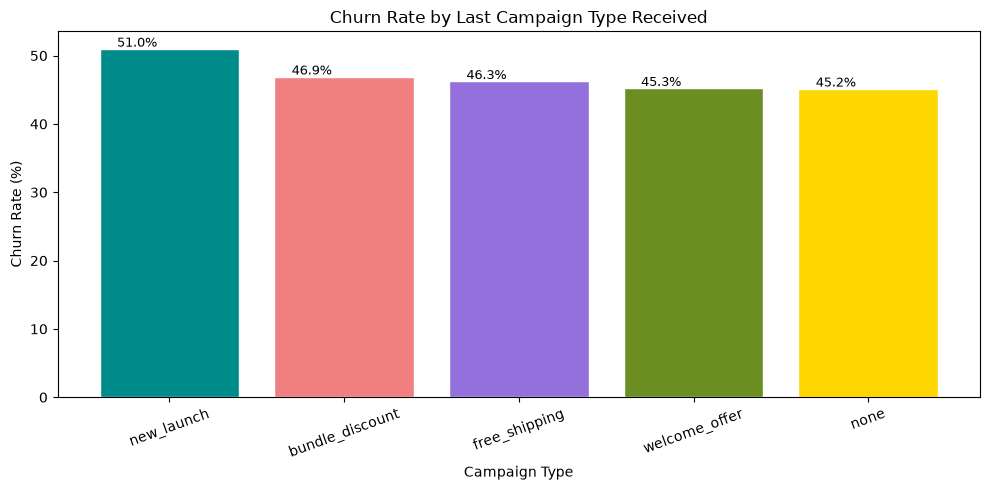

In [26]:
camp_churn = master_df.groupby('last_campaign_received')['churn_next_60d'].agg(['mean','count']).reset_index()
camp_churn['churn_rate_pct'] = camp_churn['mean'] * 100
camp_churn = camp_churn.sort_values('churn_rate_pct', ascending=False)
print(camp_churn)

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(camp_churn['last_campaign_received'], camp_churn['churn_rate_pct'], color=['darkcyan', 'lightcoral', 'mediumpurple', 'olivedrab','gold'], edgecolor='white')
ax.set_title('Churn Rate by Last Campaign Type Received')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Campaign Type')
ax.tick_params(axis='x', rotation=20)
for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%', (bar.get_x()+0.1, bar.get_height()+0.3), fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart8_campaign_vs_churn.png', dpi=120)
plt.show()

## 6. Churn-Risk Hypotheses

Each hypothesis is supported by the charts and tables above.

In [27]:
# Hypothesis 1: High recency = high churn risk
rec_means = master_df.groupby('churn_next_60d')['recency_days'].mean()
print('H1 — Recency by churn:')
print(rec_means)
print('Churned customers last ordered {:.0f} days before snapshot vs {:.0f} for non-churned.'.format(rec_means[1], rec_means[0]))
print()

# Hypothesis 2: High ticket count = high churn risk
tc_churn = master_df.groupby('ticket_bucket')['churn_next_60d'].mean() * 100
print('H2 — Ticket count vs churn rate:')
print(tc_churn)
print()

# Hypothesis 3: Non-enrolled loyalty = high churn
loy_churn2 = master_df.groupby('loyalty_tier_filled')['churn_next_60d'].mean() * 100
print('H3 — Loyalty tier vs churn rate:')
print(loy_churn2.sort_values(ascending=False))
print()

# Hypothesis 4: Low web activity = high churn
zero_sessions = master_df[master_df['sessions_30d']==0]['churn_next_60d'].mean()*100
nonzero_sessions = master_df[master_df['sessions_30d']>0]['churn_next_60d'].mean()*100
print(f'H4 — Churn rate, 0 sessions in last 30d: {zero_sessions:.1f}%')
print(f'     Churn rate, 1+ sessions in last 30d: {nonzero_sessions:.1f}%')
print()

# Hypothesis 5: customers receiving no campaign churn more
no_camp = master_df[master_df['last_campaign_received']=='none']['churn_next_60d'].mean()*100
with_camp = master_df[master_df['last_campaign_received']!='none']['churn_next_60d'].mean()*100
print(f'H5 — Churn rate, no campaign received: {no_camp:.1f}%')
print(f'     Churn rate, received a campaign  : {with_camp:.1f}%')

H1 — Recency by churn:
churn_next_60d
0     45.074627
1    135.157054
Name: recency_days, dtype: float64
Churned customers last ordered 135 days before snapshot vs 45 for non-churned.

H2 — Ticket count vs churn rate:
ticket_bucket
0 tickets     47.181266
1 ticket      50.320102
2 tickets     43.630573
3+ tickets    34.868421
Name: churn_next_60d, dtype: float64

H3 — Loyalty tier vs churn rate:
loyalty_tier_filled
Silver          48.813559
Non-enrolled    48.340548
Gold            40.752351
Platinum        37.142857
Name: churn_next_60d, dtype: float64

H4 — Churn rate, 0 sessions in last 30d: 66.3%
     Churn rate, 1+ sessions in last 30d: 45.3%

H5 — Churn rate, no campaign received: 45.2%
     Churn rate, received a campaign  : 47.4%


## Hypothesis Summary

| # | Hypothesis | Observation |
|---|---|---|
| H1 | Customers who have not placed an order recently are more likely to churn | Customers who churned had a higher average recency value, indicating a longer gap since their last purchase (Chart 4). |
| H2 | Customers with 3 or more support tickets are more likely to churn | The churn rate increased with the number of support tickets. Customers with more tickets generally showed higher churn rates (Chart 5). |
| H3 | Customers not enrolled in the loyalty programme churn more than enrolled customers | The highest churn rate was observed among customers who were not enrolled in the loyalty programme, while Platinum members had the lowest churn rate (Chart 7). |
| H4 | Customers with no web activity in the last 30 days are at higher risk of churn | Customers with zero web sessions in the last 30 days showed a noticeably higher churn rate compared to customers who were active on the website (Chart 6). |
| H5 | Customers who did not receive a marketing campaign before the snapshot date are more likely to churn | Customers who received no campaign had a higher churn rate than those who received at least one campaign before the snapshot date (Chart 8). |

## 7 Summary

In [28]:
summary = {
    'Total Customers': len(master_df),
    'Overall Churn Rate (%)': round(master_df['churn_next_60d'].mean()*100, 2),
    'Customers with No Loyalty Enrolment': master_df['loyalty_tier'].isna().sum(),
    'Customers with 0 Sessions in 30d': (master_df['sessions_30d']==0).sum(),
    'Customers with 3+ Support Tickets': (master_df['ticket_count']>=3).sum(),
    'Orders with _DUP suffix (removed)': orders['order_id'].str.endswith('_DUP').sum(),
    'Post-snapshot Orders (leakage rows)': (orders['order_date'] > SNAPSHOT_DATE).sum(),
}

for k,v in summary.items():
    print(f'{k}: {v}')

Total Customers: 2400
Overall Churn Rate (%): 46.96
Customers with No Loyalty Enrolment: 1386
Customers with 0 Sessions in 30d: 190
Customers with 3+ Support Tickets: 152
Orders with _DUP suffix (removed): 12
Post-snapshot Orders (leakage rows): 1872
